##Importamos las librerías necesarias para la lectura y tratamiento de los datos

In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Loading the 5 CSV files
maestro_tiendas = pd.read_csv('C:/Users/USUARIO/Documents/KONRAD LORENZ/MAESTRÍA/MLOPS/FORECAST/data/maestro_tiendas.csv')
inventario_actual = pd.read_csv('C:/Users/USUARIO/Documents/KONRAD LORENZ/MAESTRÍA/MLOPS/FORECAST/data/inventario_actual.csv')
catalogo_productos = pd.read_csv('C:/Users/USUARIO/Documents/KONRAD LORENZ/MAESTRÍA/MLOPS/FORECAST/data/catalogo_productos.csv')
ventas_historicas = pd.read_csv('C:/Users/USUARIO/Documents/KONRAD LORENZ/MAESTRÍA/MLOPS/FORECAST/data/ventas_historicas.csv')
ground_truth_trends = pd.read_csv('C:/Users/USUARIO/Documents/KONRAD LORENZ/MAESTRÍA/MLOPS/FORECAST/data/ground_truth_trends.csv')

# Displaying the first few rows of one to confirm loading
print("Files loaded successfully.")
display(ventas_historicas.head())

Files loaded successfully.


,fecha,id_tienda,id_producto,unidades_vendidas
0,2024-01-01,STORE_01,PROD_001,5
1,2024-01-02,STORE_01,PROD_001,4
2,2024-01-03,STORE_01,PROD_001,3
3,2024-01-04,STORE_01,PROD_001,4
4,2024-01-05,STORE_01,PROD_001,10


### Corrección de Caracteres Especiales (Encoding)
Si los archivos presentan errores como 'BogotÃ¡' en lugar de 'Bogotá', aplicaremos una función para corregir la codificación y normalizar el texto (quitar tildes si es necesario para el modelo).

In [8]:
import unicodedata

def corregir_encoding(texto):
    if not isinstance(texto, str):
        return texto
    try:
        # Intenta corregir el error común de UTF-8 interpretado como Latin-1
        texto_corregido = texto.encode('latin-1').decode('utf-8')
    except (UnicodeEncodeError, UnicodeDecodeError):
        texto_corregido = texto

    # Opcional: Eliminar tildes y caracteres especiales para consistencia en el modelo
    texto_normalizado = "".join(
        c for c in unicodedata.normalize('NFD', texto_corregido)
        if unicodedata.category(c) != 'Mn'
    )
    return texto_normalizado

# Aplicar corrección a las columnas de texto
maestro_tiendas['ciudad'] = maestro_tiendas['ciudad'].apply(corregir_encoding)
catalogo_productos['nombre'] = catalogo_productos['nombre'].apply(corregir_encoding)

print("Datos corregidos:")
display(maestro_tiendas.head())
display(catalogo_productos.head())

Datos corregidos:


,id_tienda,ciudad,tamaño_m2
0,STORE_01,Bogota,28
1,STORE_02,Bogota,43
2,STORE_03,Bogota,42
3,STORE_04,Cali,40
4,STORE_05,Bogota,34


,id_producto,nombre,categoria,costo_unitario,precio_venta,costo_almacenamiento_semanal
0,PROD_001,Tinto,Bebidas,800,2500,10
1,PROD_002,Cafe con Leche,Bebidas,1200,3500,15
2,PROD_003,Cappuccino,Bebidas,1500,4500,15
3,PROD_004,Pan de Bono,Alimentos,1000,2800,20
4,PROD_005,Bunuelo,Alimentos,800,2500,20


##Relacionamos las tablas utilizando "id_tienda", "id_producto" con el comando merge, esto para unificar las 5 tablas y formar un único dataset con el cual vamos a trabajar

In [9]:
# Unir ventas_historicas con la información de maestro_tiendas
# Seleccionamos solo las columnas necesarias de maestro_tiendas para evitar duplicados
df_final = ventas_historicas.merge(
    maestro_tiendas[['id_tienda', 'ciudad', 'tamaño_m2']],
    on='id_tienda',
    how='left'
)

# Verificar el resultado
print("Dataset enriquecido con información de tiendas:")
display(df_final.head())

Dataset enriquecido con información de tiendas:


,fecha,id_tienda,id_producto,unidades_vendidas,ciudad,tamaño_m2
0,2024-01-01,STORE_01,PROD_001,5,Bogota,28
1,2024-01-02,STORE_01,PROD_001,4,Bogota,28
2,2024-01-03,STORE_01,PROD_001,3,Bogota,28
3,2024-01-04,STORE_01,PROD_001,4,Bogota,28
4,2024-01-05,STORE_01,PROD_001,10,Bogota,28


In [10]:
# 1. Unir con catálogo de productos
df_final = df_final.merge(catalogo_productos, on='id_producto', how='left')

# 2. Unir con inventario actual
df_final = df_final.merge(inventario_actual, on=['id_tienda', 'id_producto'], how='left')

# 3. Unir con tendencias (ground truth)
df_final = df_final.merge(ground_truth_trends, on=['id_tienda', 'id_producto'], how='left')

print("Dataset consolidado final:")
display(df_final.head())
print(f"\nDimensiones finales: {df_final.shape}")

Dataset consolidado final:


,fecha,id_tienda,id_producto,unidades_vendidas,ciudad,tamaño_m2,nombre,categoria,costo_unitario,precio_venta,costo_almacenamiento_semanal,stock_actual,trend_type
0,2024-01-01,STORE_01,PROD_001,5,Bogota,28,Tinto,Bebidas,800,2500,10,1,up
1,2024-01-02,STORE_01,PROD_001,4,Bogota,28,Tinto,Bebidas,800,2500,10,1,up
2,2024-01-03,STORE_01,PROD_001,3,Bogota,28,Tinto,Bebidas,800,2500,10,1,up
3,2024-01-04,STORE_01,PROD_001,4,Bogota,28,Tinto,Bebidas,800,2500,10,1,up
4,2024-01-05,STORE_01,PROD_001,10,Bogota,28,Tinto,Bebidas,800,2500,10,1,up



Dimensiones finales: (14560, 13)


##Obtenemos la información general del dataset resultante

In [11]:
# 1. Información general y tipos de datos
print("--- Información del Dataset ---")
display(df_final.info())

# 2. Revisión de valores nulos
print("\n--- Valores Nulos ---")
print(df_final.isnull().sum())

# 3. Convertir fecha a datetime para facilitar el análisis temporal
df_final['fecha'] = pd.to_datetime(df_final['fecha'])

# 4. Estadísticas descriptivas de las ventas
print("\n--- Resumen Estadístico de Unidades Vendidas ---")
display(df_final['unidades_vendidas'].describe())

--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 14560 entries, 0 to 14559
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   fecha                         14560 non-null  str  
 1   id_tienda                     14560 non-null  str  
 2   id_producto                   14560 non-null  str  
 3   unidades_vendidas             14560 non-null  int64
 4   ciudad                        14560 non-null  str  
 5   tamaño_m2                     14560 non-null  int64
 6   nombre                        14560 non-null  str  
 7   categoria                     14560 non-null  str  
 8   costo_unitario                14560 non-null  int64
 9   precio_venta                  14560 non-null  int64
 10  costo_almacenamiento_semanal  14560 non-null  int64
 11  stock_actual                  14560 non-null  int64
 12  trend_type                    14560 non-null  str  
dtypes: int64(6

None


--- Valores Nulos ---
fecha                           0
id_tienda                       0
id_producto                     0
unidades_vendidas               0
ciudad                          0
tamaño_m2                       0
nombre                          0
categoria                       0
costo_unitario                  0
precio_venta                    0
costo_almacenamiento_semanal    0
stock_actual                    0
trend_type                      0
dtype: int64

--- Resumen Estadístico de Unidades Vendidas ---


count    14560.000000
mean        13.177266
std          7.791471
min          0.000000
25%          7.000000
50%         12.000000
75%         17.000000
max         58.000000
Name: unidades_vendidas, dtype: float64

### Análisis Univariado: Distribución de Ventas
Visualizamos la concentración de las ventas para identificar sesgos o valores atípicos.

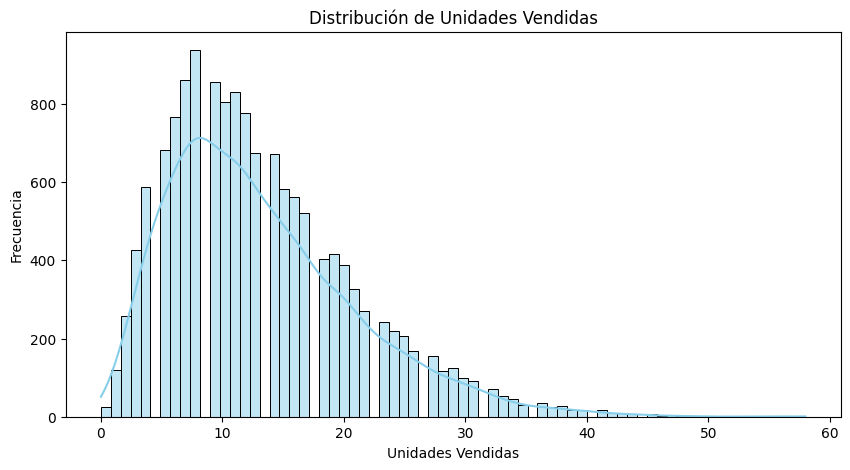

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df_final['unidades_vendidas'], kde=True, color='skyblue')
plt.title('Distribución de Unidades Vendidas')
plt.xlabel('Unidades Vendidas')
plt.ylabel('Frecuencia')
plt.show()

### Productos Más Vendidos

Top 10 Productos Más Vendidos:


nombre
Bunuelo            32489
Pastel de Pollo    31469
Jugo de Naranja    29833
Croissant          28895
Cappuccino         21249
Cafe con Leche     20580
Tinto              14971
Pan de Bono        12375
Name: unidades_vendidas, dtype: int64

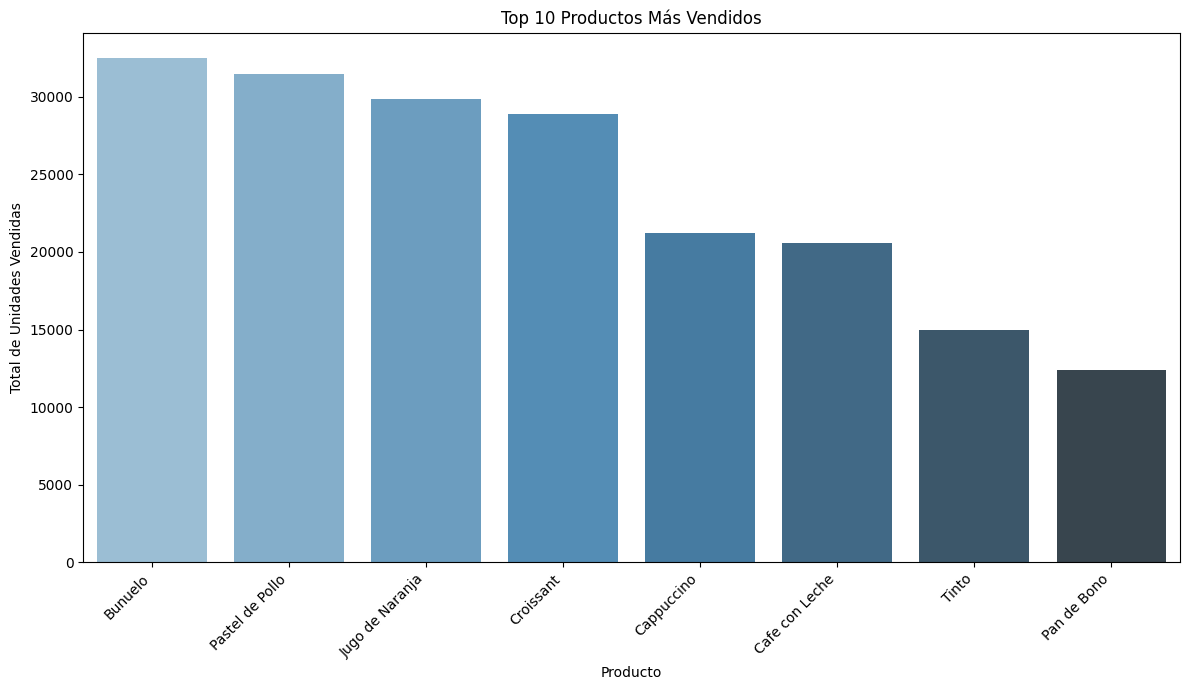

In [13]:
top_products = df_final.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(10)

print("Top 10 Productos Más Vendidos:")
display(top_products)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_products.index, y=top_products.values, hue=top_products.index, palette='Blues_d', legend=False)
plt.title('Top 10 Productos Más Vendidos')
plt.xlabel('Producto')
plt.ylabel('Total de Unidades Vendidas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Influencia del Tamaño de la Tienda en las Unidades Vendidas

In [14]:
correlation_size_sales = df_final['tamaño_m2'].corr(df_final['unidades_vendidas'])
print(f"Correlación entre Tamaño de la Tienda (m2) y Unidades Vendidas: {correlation_size_sales:.2f}")

Correlación entre Tamaño de la Tienda (m2) y Unidades Vendidas: 0.43


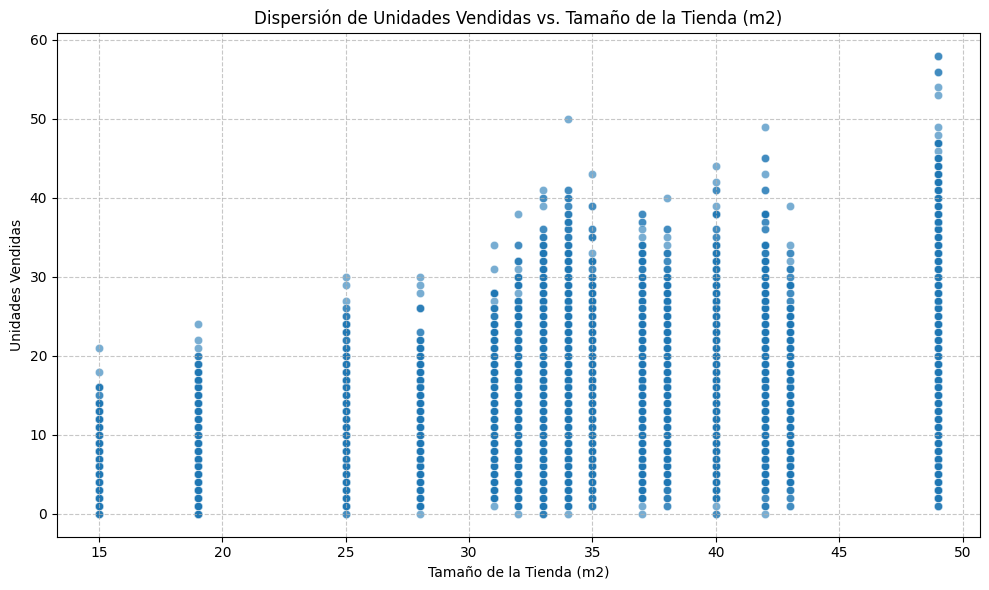

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tamaño_m2', y='unidades_vendidas', data=df_final, alpha=0.6)
plt.title('Dispersión de Unidades Vendidas vs. Tamaño de la Tienda (m2)')
plt.xlabel('Tamaño de la Tienda (m2)')
plt.ylabel('Unidades Vendidas')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Distribución de Unidades Vendidas por Categoría de Producto

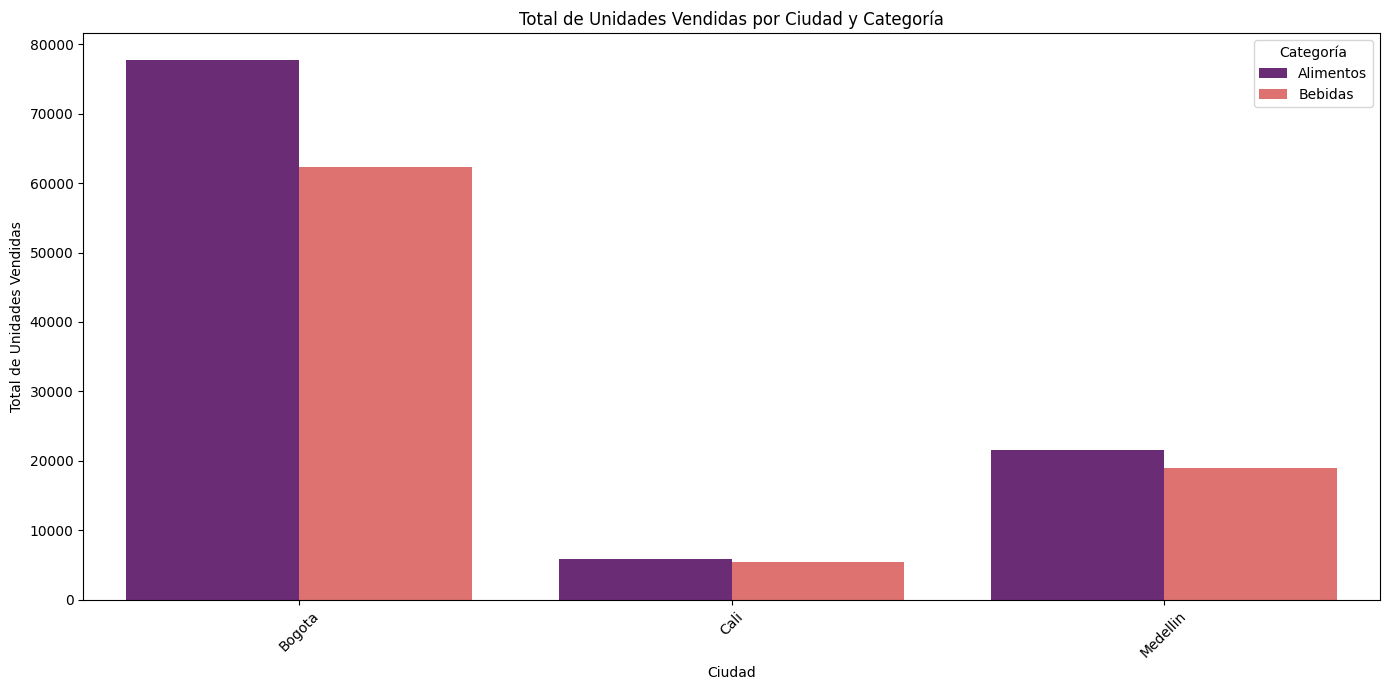

In [22]:
# Agrupar ventas por ciudad y categoría
ventas_por_ciudad_categoria = df_final.groupby(['ciudad', 'categoria'])['unidades_vendidas'].sum().reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(x='ciudad', y='unidades_vendidas', hue='categoria', data=ventas_por_ciudad_categoria, palette='magma')
plt.title('Total de Unidades Vendidas por Ciudad y Categoría')
plt.xlabel('Ciudad')
plt.ylabel('Total de Unidades Vendidas')
plt.xticks(rotation=45)
plt.legend(title='Categoría')
plt.tight_layout()
plt.show()

### Análisis Bivariado: Ventas por Categoría y Tiempo
Exploramos la relación entre las ventas y factores clave como el tipo de producto y el comportamiento semanal.

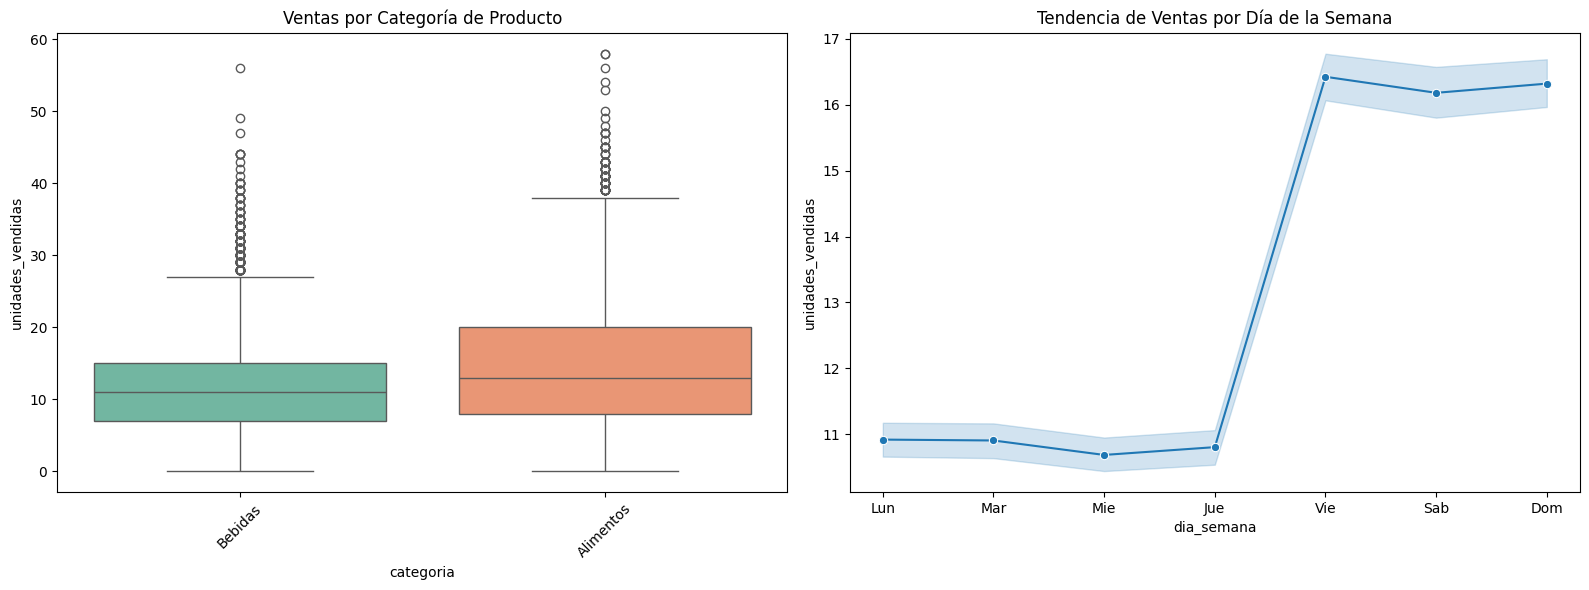

In [23]:
df_final['dia_semana'] = df_final['fecha'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ventas por Categoría
sns.boxplot(ax=axes[0], x='categoria', y='unidades_vendidas', hue='categoria', data=df_final, palette='Set2', legend=False)
axes[0].set_title('Ventas por Categoría de Producto')
axes[0].tick_params(axis='x', rotation=45)

# Ventas por Día de la Semana (0=Lunes, 6=Domingo)
sns.lineplot(ax=axes[1], x='dia_semana', y='unidades_vendidas', data=df_final, marker='o')
axes[1].set_title('Tendencia de Ventas por Día de la Semana')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom'])

plt.tight_layout()
plt.show()

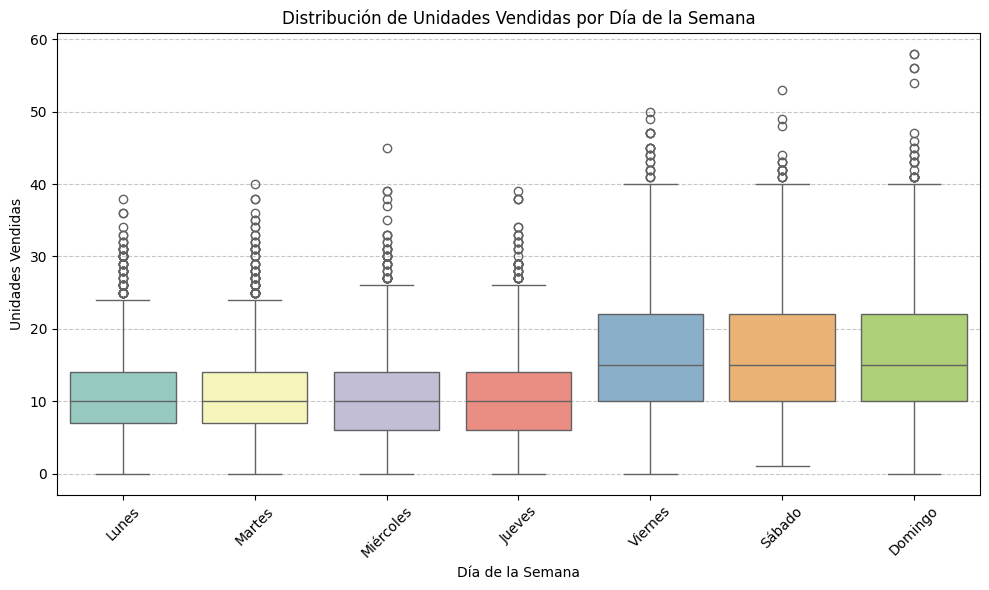

In [24]:
# Map day numbers to names for better readability on the plot
day_names = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df_final['dia_semana_nombre'] = df_final['dia_semana'].map(lambda x: day_names[x])

plt.figure(figsize=(10, 6))
sns.boxplot(x='dia_semana_nombre', y='unidades_vendidas', hue='dia_semana_nombre', data=df_final, palette='Set3', legend=False)
plt.title('Distribución de Unidades Vendidas por Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

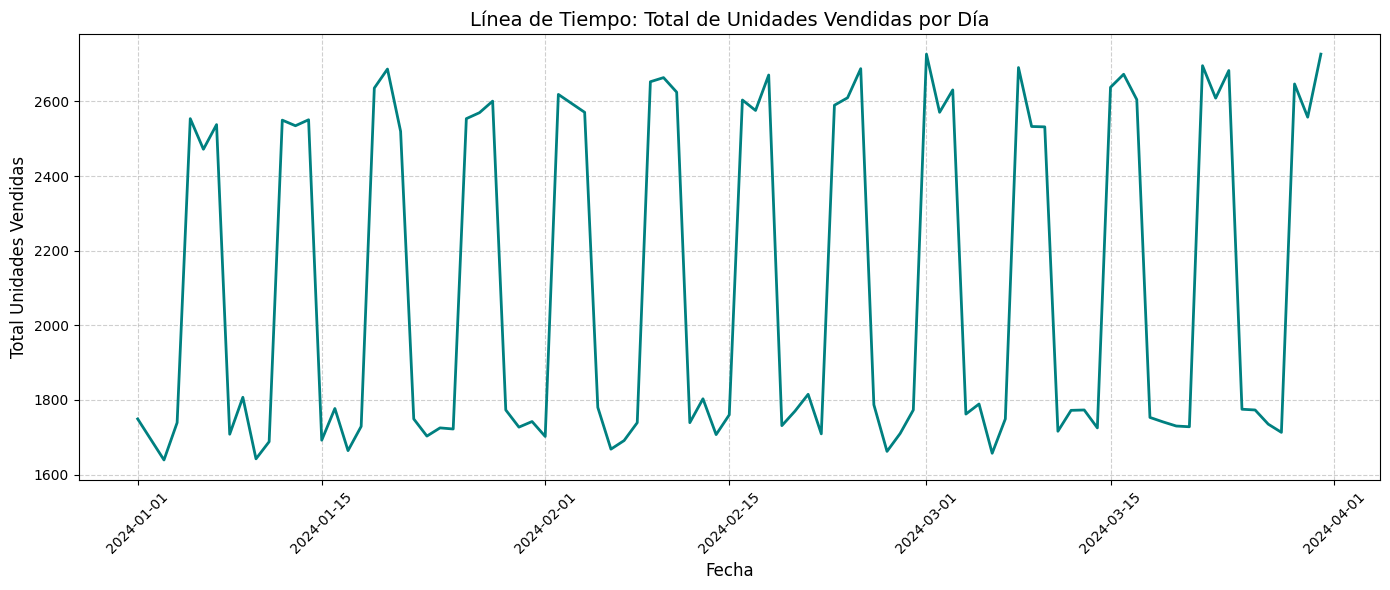

In [25]:
# Agrupar las ventas por fecha para obtener el total diario
ventas_diarias = df_final.groupby('fecha')['unidades_vendidas'].sum().reset_index()

# Crear la visualización de la línea de tiempo
plt.figure(figsize=(14, 6))
sns.lineplot(data=ventas_diarias, x='fecha', y='unidades_vendidas', color='teal', linewidth=2)

plt.title('Línea de Tiempo: Total de Unidades Vendidas por Día', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Total Unidades Vendidas', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##Mapa de calor de correlaciones

##Identificamos las variables más correlacionadas con nuestra variable objetivo "unidades_vendidas"

Nuevas correlaciones (incluyendo categóricas codificadas con la variable objetivo UNIDADES_VENDIDAS):


unidades_vendidas               1.000000
tamaño_m2                       0.425502
id_producto                     0.387674
costo_almacenamiento_semanal    0.297923
dia_semana                      0.297735
costo_unitario                  0.199778
precio_venta                    0.152763
trend_type                      0.062272
stock_actual                    0.033891
id_tienda                       0.009481
ciudad                         -0.135021
categoria                      -0.163919
Name: unidades_vendidas, dtype: float64

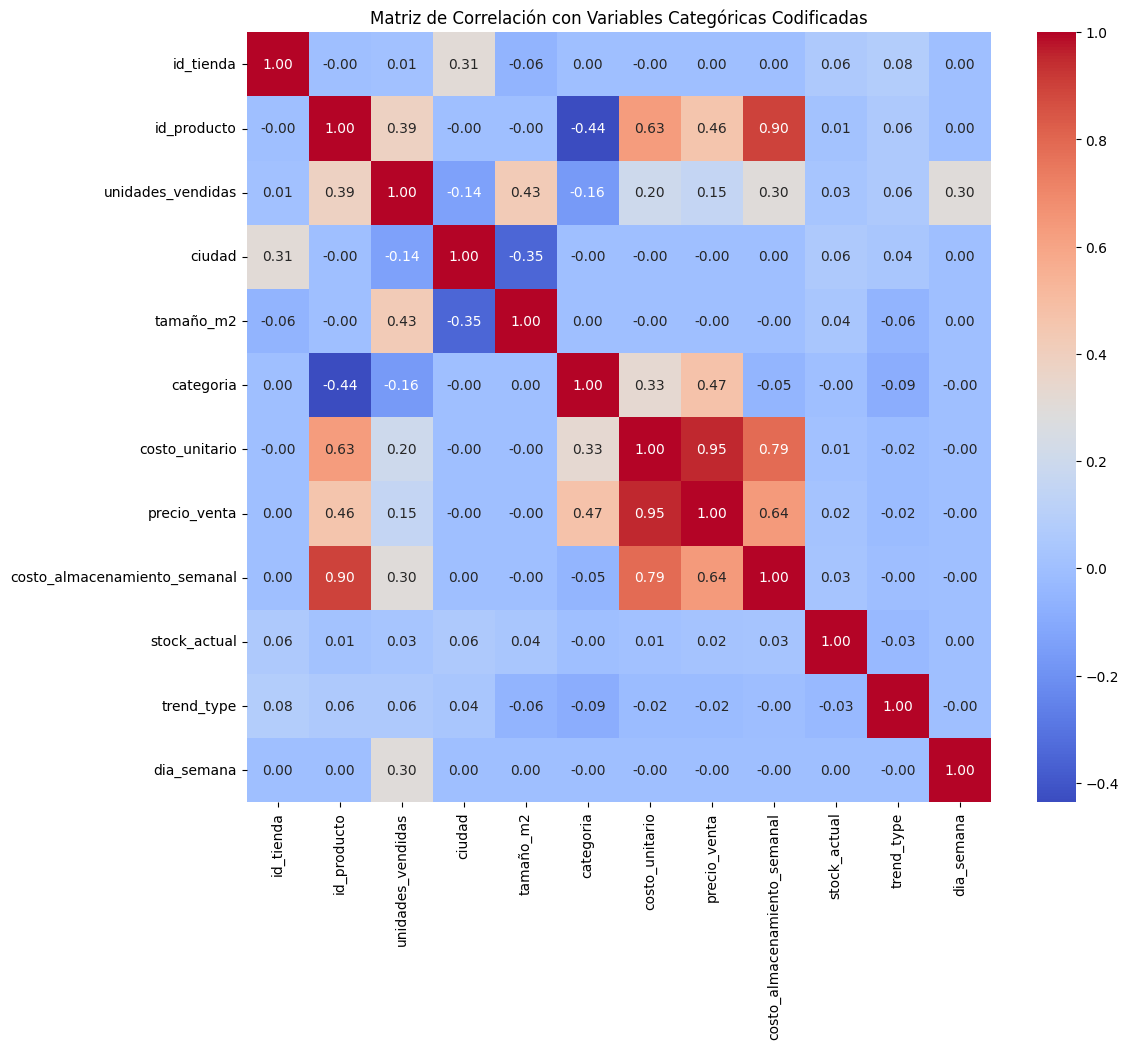

In [28]:
from sklearn.preprocessing import LabelEncoder

# Crear una copia para no alterar el dataframe original de trabajo
df_analisis = df_final.copy()

# Columnas categóricas a codificar
columnas_cat = ['id_tienda', 'id_producto', 'ciudad', 'categoria', 'trend_type']

le = LabelEncoder()
for col in columnas_cat:
    df_analisis[col] = le.fit_transform(df_analisis[col])

# Recalcular la matriz de correlación incluyendo ahora las categóricas codificadas
corr_expandida = df_analisis.select_dtypes(include=[np.number]).corr()

print("Nuevas correlaciones (incluyendo categóricas codificadas con la variable objetivo UNIDADES_VENDIDAS):")
display(corr_expandida['unidades_vendidas'].sort_values(ascending=False))

# Visualizar el nuevo mapa de calor
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(corr_expandida, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación con Variables Categóricas Codificadas')
plt.show()